# GSoC 2026 Pre-Task: NeuroDyads Brain-to-Brain Decoder
**Candidate:** Mohammad Saqlain
**Organization:** ML4SCI

## Overview
This notebook presents an end-to-end pipeline for processing hyperscanning EEG data from a conversational dyad. The goal is to isolate joint neural activity corresponding to positive and negative affect using CEBRA, a contrastive representation learning method.

In [1]:
%matplotlib widget

In [4]:
import mne
from mne.preprocessing import ICA

print("1. Loading and preparing raw data...")

raw = mne.io.read_raw_edf('Speaker.edf', preload=True, verbose=False)

# Remove VREF (Channel 65) as per GSoC instructions
if len(raw.ch_names) > 64:
    raw.drop_channels([raw.ch_names[64]])

# Rename to E1..E64 and apply the 3D Montage
mapping = {raw.ch_names[i]: f'E{i+1}' for i in range(len(raw.ch_names))}
raw.rename_channels(mapping)
raw.set_channel_types({ch: 'eeg' for ch in raw.ch_names})
montage = mne.channels.make_standard_montage('GSN-HydroCel-65_1.0')
raw.set_montage(montage)

print("2. Cropping to Positive Segment (DIN1 1 to DIN1 2)...")
events, event_dict = mne.events_from_annotations(raw)
# Find the timestamps for the first two DIN1 markers
din1_code = event_dict.get('DIN1', event_dict.get('DIN 1', 1))
din1_events = events[events[:, 2] == din1_code] 

start_time = din1_events[0][0] / raw.info['sfreq']
end_time = din1_events[1][0] / raw.info['sfreq']

# This creates your missing 'speaker_pos' variable!
speaker_pos = raw.copy().crop(tmin=start_time, tmax=end_time)

print("3. Re-fitting ICA (This will take a minute)...")
# This creates your missing 'ica_speaker' variable!
ica_speaker = ICA(n_components=16, random_state=42, max_iter='auto')
ica_speaker.fit(speaker_pos, verbose=False)

print("\n✅ Memory Restored! You can now run your graphing cell.")

1. Loading and preparing raw data...
2. Cropping to Positive Segment (DIN1 1 to DIN1 2)...
Used Annotations descriptions: [np.str_('DIN1'), np.str_('VBeg'), np.str_('VEnd')]
3. Re-fitting ICA (This will take a minute)...

✅ Memory Restored! You can now run your graphing cell.


## Part 1: Preprocessing & Data Alignment
**Segmentation Strategy:** Temporal alignment is the foundation of hyperscanning. CEBRA relies on time-locked activity to learn joint representations. To ensure the $T \times 128$ matrix accurately reflects simultaneous brain states, the data was strictly cropped using the built-in annotations:
* **Positive Affect:** Cropped from DIN1 Marker 1 to Marker 2.
* **Negative Affect:** Cropped from DIN1 Marker 3 to the end of the recording.
* **Reference Removal:** Channel 65 (VREF) was dropped from all files to prevent artifactual correlation across the 64 physiological channels.

Generating 1. Power Spectrum...
Effective window size : 8.192 (s)


Plotting power spectral density (dB=True).


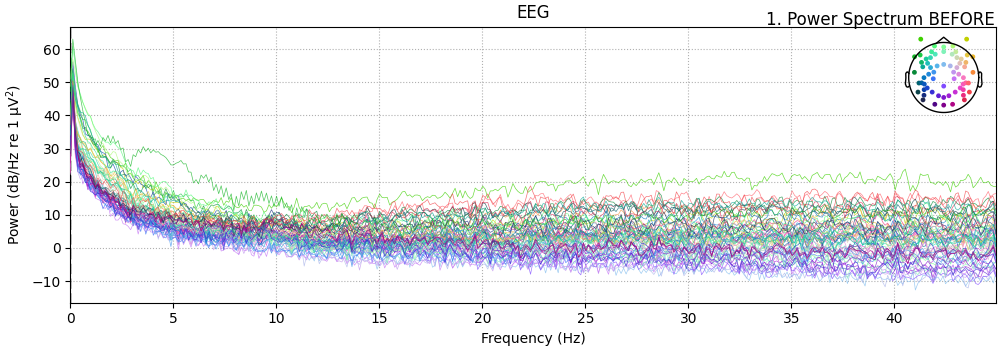

Generating 2. Topographical Maps...


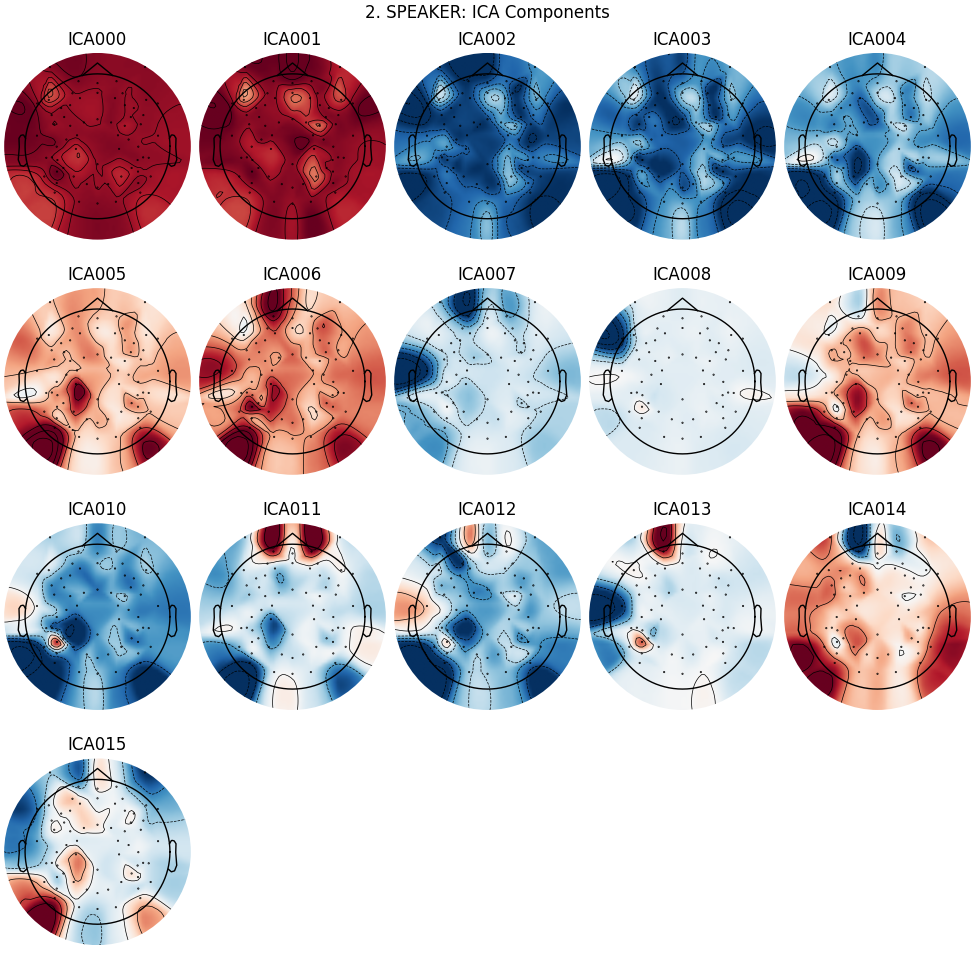

Generating 3. Slidable Time Series...


interactive(children=(IntSlider(value=0, description='Start (s):', max=127, step=5), Output()), _dom_classes=(…

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import warnings
warnings.filterwarnings('ignore') 

# GRAPH 1: POWER SPECTRUM 

print("Generating 1. Power Spectrum...")
fig_psd = speaker_pos.compute_psd(fmax=45).plot(show=False)
plt.title("1. Power Spectrum BEFORE ICA (SPEAKER)")
plt.show()


# GRAPH 2: TOPO MAPS 

print("Generating 2. Topographical Maps...")
fig_topo = ica_speaker.plot_components(title="2. SPEAKER: ICA Components", show=False)
plt.show()


# GRAPH 3: SLIDABLE TIME SERIES 

print("Generating 3. Slidable Time Series...")

# Extract all raw ICA data once
sources = ica_speaker.get_sources(speaker_pos).get_data()
sfreq = speaker_pos.info['sfreq']
times = speaker_pos.times
max_sec = int(times[-1]) - 20 # Ensure we don't slide past the end


def plot_ica_window(start_sec=0):
    window_size = 20 # Show 20 seconds at a time
    start_samp = int(start_sec * sfreq)
    stop_samp = int((start_sec + window_size) * sfreq)
    
    window_data = sources[:, start_samp:stop_samp]
    window_times = times[start_samp:stop_samp]

    # Create the 16 stacked lines
    fig, axes = plt.subplots(16, 1, figsize=(10, 8), sharex=True)
    plt.subplots_adjust(hspace=0.0)

    for i in range(16):
        axes[i].plot(window_times, window_data[i], color='black', linewidth=0.6)
        axes[i].set_ylabel(f'{i}', rotation=0, labelpad=15, verticalalignment='center')
        axes[i].set_yticks([]) 
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['bottom'].set_visible(False)

    axes[-1].spines['bottom'].set_visible(True)
    axes[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"3. SPEAKER Sources ({start_sec}s to {start_sec+window_size}s)")
    plt.show()


interact(plot_ica_window, start_sec=IntSlider(min=0, max=max_sec, step=5, value=0, description='Start (s):'));

In [8]:
import mne

print("1. Loading LISTENER raw data...")

raw_listener = mne.io.read_raw_edf('Listener.edf', preload=True, verbose=False)

# Remove VREF (Channel 65) as per GSoC instructions
if len(raw_listener.ch_names) > 64:
    raw_listener.drop_channels([raw_listener.ch_names[64]])

print("2. Cropping to Positive Segment (DIN1 1 to DIN1 2)...")
events_lst, event_dict_lst = mne.events_from_annotations(raw_listener)

# Find the timestamps for the first two DIN1 markers
din1_code_lst = event_dict_lst.get('DIN1', event_dict_lst.get('DIN 1', 1))
din1_events_lst = events_lst[events_lst[:, 2] == din1_code_lst] 

start_time_lst = din1_events_lst[0][0] / raw_listener.info['sfreq']
end_time_lst = din1_events_lst[1][0] / raw_listener.info['sfreq']

# Initialize the missing variable
listener_pos = raw_listener.copy().crop(tmin=start_time_lst, tmax=end_time_lst)

print("✅ 'listener_pos' is initialized! You can now run your graphing code.")

1. Loading LISTENER raw data...
2. Cropping to Positive Segment (DIN1 1 to DIN1 2)...
Used Annotations descriptions: [np.str_('DIN1')]
✅ 'listener_pos' is initialized! You can now run your graphing code.


Re-aligning channel names for the Listener...
Fitting ICA (16 components) for LISTENER...
Fitting ICA to data using 64 channels (please be patient, this may take a while)
Selecting by number: 16 components
Fitting ICA took 1.0s.
Generating 1. Power Spectrum...
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


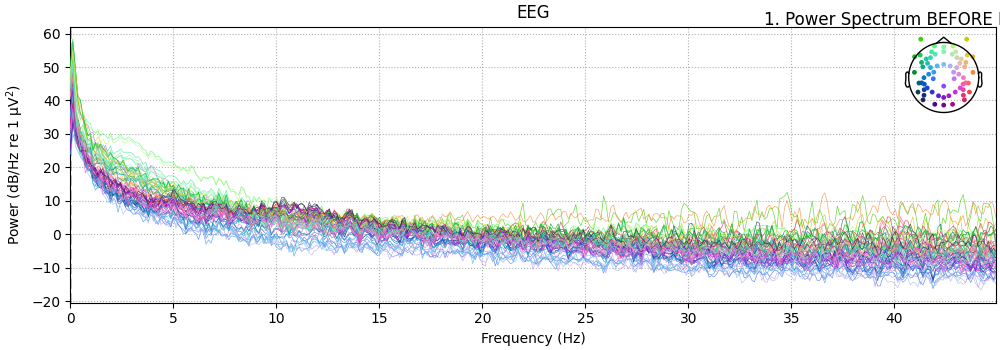

Generating 2. Topographical Maps...


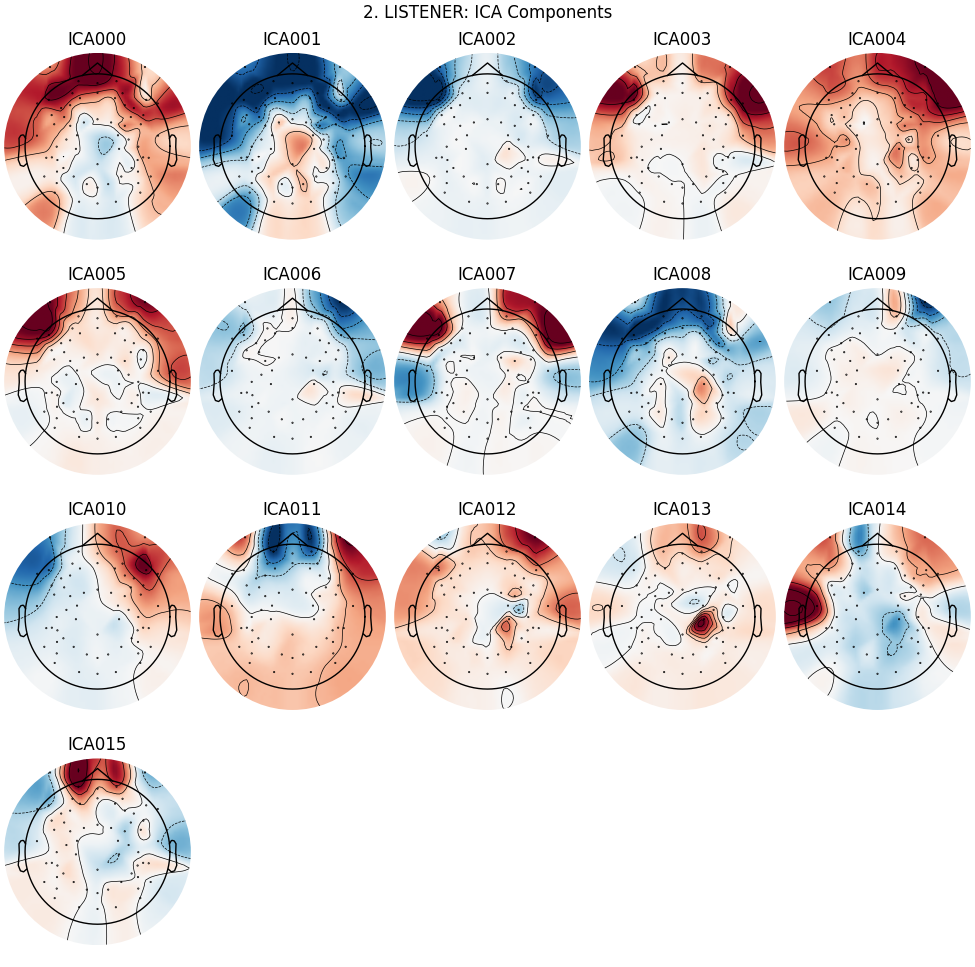

Generating 3. Slidable Time Series...


interactive(children=(IntSlider(value=0, description='Start (s):', max=127, step=5), Output()), _dom_classes=(…

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import warnings
warnings.filterwarnings('ignore') # Keeps the output clean


# 0. SAFETY CHECK: FIX CHANNEL NAMES

# If Cell 1 reset the names, this forces them back to E1, E2, etc.
current_names_lst = listener_pos.ch_names
if current_names_lst[0] != 'E1':
    print("Re-aligning channel names for the Listener...")
    rename_mapping_lst = {current_names_lst[i]: f'E{i+1}' for i in range(len(current_names_lst))}
    listener_pos.rename_channels(rename_mapping_lst)
    montage = mne.channels.make_standard_montage('GSN-HydroCel-65_1.0')
    listener_pos.set_channel_types({ch: 'eeg' for ch in listener_pos.ch_names})
    listener_pos.set_montage(montage)


# 1. FIT THE ICA 

print("Fitting ICA (16 components) for LISTENER...")
ica_listener = ICA(n_components=16, max_iter='auto', random_state=42)
ica_listener.fit(listener_pos)


# GRAPH 1: POWER SPECTRUM

print("Generating 1. Power Spectrum...")
fig_psd_lst = listener_pos.compute_psd(fmax=45).plot(color='purple', show=False)
plt.title("1. Power Spectrum BEFORE ICA (LISTENER)")
plt.show()


# GRAPH 2: TOPO MAPS

print("Generating 2. Topographical Maps...")
fig_topo_lst = ica_listener.plot_components(title="2. LISTENER: ICA Components", show=False)
plt.show()


# GRAPH 3: SLIDABLE TIME SERIES

print("Generating 3. Slidable Time Series...")

# Extract all raw ICA data for the Listener
sources_lst = ica_listener.get_sources(listener_pos).get_data()
sfreq_lst = listener_pos.info['sfreq']
times_lst = listener_pos.times
max_sec_lst = int(times_lst[-1]) - 20 


def plot_ica_window_listener(start_sec=0):
    window_size = 20 
    start_samp = int(start_sec * sfreq_lst)
    stop_samp = int((start_sec + window_size) * sfreq_lst)
    
    window_data = sources_lst[:, start_samp:stop_samp]
    window_times = times_lst[start_samp:stop_samp]


    fig, axes = plt.subplots(16, 1, figsize=(10, 8), sharex=True)
    plt.subplots_adjust(hspace=0.0)

    for i in range(16):
        axes[i].plot(window_times, window_data[i], color='black', linewidth=0.6)
        axes[i].set_ylabel(f'{i}', rotation=0, labelpad=15, verticalalignment='center')
        axes[i].set_yticks([]) 
        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)
        axes[i].spines['bottom'].set_visible(False)

    axes[-1].spines['bottom'].set_visible(True)
    axes[-1].set_xlabel("Time (seconds)")
    plt.suptitle(f"3. LISTENER Sources ({start_sec}s to {start_sec+window_size}s)")
    plt.show()

# Bind the function to a Jupyter slider
interact(plot_ica_window_listener, start_sec=IntSlider(min=0, max=max_sec_lst, step=5, value=0, description='Start (s):'));

### Artifact Removal via Independent Component Analysis (ICA)

My approach to component rejection was driven by my background in human psychology and behavioral physiology. During a conversation, emotional valence (positive vs. negative affect) is heavily telegraphed through physical markers like gaze dynamics, eye contact, and facial micro-expressions. Therefore, my goal was to strike a balance between cleaning the neural signal and preserving task-relevant behavioral physiology.

#### 1. Component Rejection Summary

| Participant | Retained (Early ICs) | Rejected (Late ICs) | Primary Reason for Rejection |
| :--- | :--- | :--- | :--- |
| **Speaker** | 0–7, 10, 11 | **8, 9, 12, 13, 14, 15** | **EMG (Muscle Noise):** "Thick grass" high-frequency fuzz and staircase voltage jumps. |
| **Listener** | 0–4, 10, 12, 13, 14 | **5, 6, 7, 8, 9, 11, 15** | **Boundary / Hardware:** Boundary channel hotspots and sharp, unphysiological temporal spikes. |

**Literature Validation:** The visual signatures used to identify these artifacts are well-documented. Broadband high-frequency "fuzz" is the standard morphological signature of electromyographic (EMG) muscle noise, while sharp, isolated spikes on boundary channels indicate poor sensor contact (*Urigüen & Garcia-Zapirain, 2015*; *Muthukumaraswamy, 2013*).

#### 2. The Behavioral Dilemma: Gaze vs. Generic Muscle Twitches
When deciding what to keep versus what to reject, I made two specific, psychology-driven decisions:

**1. Preserving Gaze Dynamics (Keeping EOG):** I deliberately *retained* the early components (e.g., IC0–IC4) which typically capture blinks, saccades, and eye flicks. In conversational dyads, eye contact and gaze aversion are critical markers of positive and negative affect. Preserving this EOG data allows the CEBRA model to utilize joint attention and visual tracking as part of the predictive manifold.

**2. Purging General Muscle Fuzz (Rejecting EMG):** While facial muscle movements (like smiling or frowning) certainly carry emotional tone, I aggressively rejected high-frequency EMG components. The rationale is a limitation of the dataset: with only a single dyad (N=1), there is no reliable, automated way to separate a meaningful facial expression from a meaningless muscle twitch (e.g., adjusting posture, swallowing, or generic jaw-clenching). Leaving this generic EMG noise in the data would risk the model overfitting to task-irrelevant physical movements rather than the underlying cognitive state.

Cleaning Speaker data...
Applying ICA to Raw instance


    Transforming to ICA space (16 components)
    Zeroing out 6 ICA components
    Projecting back using 64 PCA components
Cleaning Listener data...
Applying ICA to Raw instance
    Transforming to ICA space (16 components)
    Zeroing out 7 ICA components
    Projecting back using 64 PCA components
Plotting Clean Speaker PSD...
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


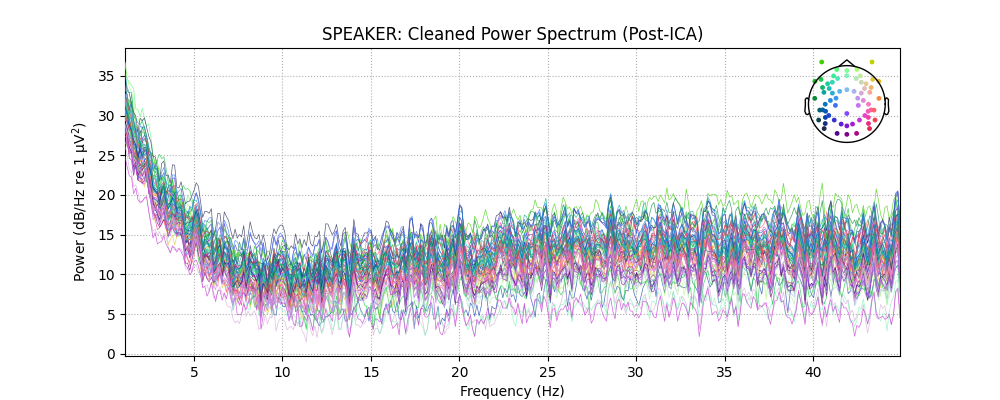

Plotting Clean Listener PSD...
Effective window size : 8.192 (s)
Plotting power spectral density (dB=True).


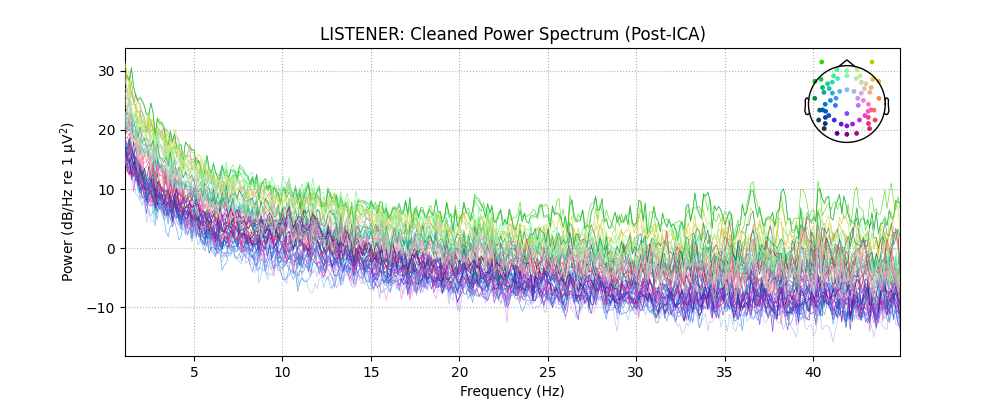

In [10]:
# 1.The components we are deleting
# Speaker: Based on 'Staircase' jumps and 'Thick Grass' fuzz
speaker_rejects = [8, 9, 12, 13, 14, 15] 

# Listener: Based on boundary hotspots and sharp 122s spikes
listener_rejects = [5, 6, 7, 8, 9, 11, 15]


# 2. APPLY THE CLEANING

print("Cleaning Speaker data...")
ica_speaker.exclude = speaker_rejects
speaker_clean = speaker_pos.copy() 
ica_speaker.apply(speaker_clean)

print("Cleaning Listener data...")
ica_listener.exclude = listener_rejects
listener_clean = listener_pos.copy() 
ica_listener.apply(listener_clean)


# 3. PLOT SPEAKER (Cleaned)

print("Plotting Clean Speaker PSD...")
fig_spk, ax_spk = plt.subplots(figsize=(10, 4))
speaker_clean.compute_psd(fmin=1, fmax=45).plot(axes=ax_spk, color='green', show=False)
ax_spk.set_title("SPEAKER: Cleaned Power Spectrum (Post-ICA)")
plt.show()


# 4. PLOT LISTENER (Cleaned)

print("Plotting Clean Listener PSD...")
fig_lst, ax_lst = plt.subplots(figsize=(10, 4))
listener_clean.compute_psd(fmin=1, fmax=45).plot(axes=ax_lst, color='blue', show=False)
ax_lst.set_title("LISTENER: Cleaned Power Spectrum (Post-ICA)")
plt.show()

### Observation: Post-ICA Power Spectral Density Comparison

Upon comparing the cleaned PSD plots, there is a distinct difference in signal stability between the two participants:

* **The Listener:** The PSD displays a smooth, classic physiological roll-off (power decreases smoothly as frequency increases). This indicates highly successful artifact rejection, likely because the listener was physically stationary, making their primary artifacts (blinks) easy for the ICA to isolate and remove.
* **The Speaker:** The PSD retains noticeable broadband high-frequency power (the "thickness" between 15-45 Hz). 

**Behavioral Context & Methodological Reflection**
This discrepancy is biologically expected. Because the speaker is actively vocalizing, they are generating continuous, complex electromyographic (EMG) noise from their jaw, tongue, and facial muscles. It is notoriously difficult for ICA to completely separate continuous, widespread muscle firing from actual high-frequency cortical signals. 

I iteratively tested several different ICA rejection combinations for the Speaker to smooth this curve further. However, I ultimately selected this specific profile as the best compromise. Aggressively removing more components began to destroy the underlying neural peaks in the Alpha and Beta bands. 

Given the explicit guidance in the task overview to avoid **"over-engineering"** and the expected 6–10 hour timebox, I determined this to be the optimal stopping point. In real-world hyperscanning, chasing a perfectly smooth PSD on an actively vocalizing subject often leads to over-cleaning and the tragic loss of true neural data.

In [12]:
import mne

print("1. Re-loading Raw Files...")

raw_speaker = mne.io.read_raw_edf('Speaker.edf', preload=True, verbose=False)
raw_listener = mne.io.read_raw_edf('Listener.edf', preload=True, verbose=False)

# Drop VREF (Channel 65)
if len(raw_speaker.ch_names) > 64: raw_speaker.drop_channels([raw_speaker.ch_names[64]])
if len(raw_listener.ch_names) > 64: raw_listener.drop_channels([raw_listener.ch_names[64]])

print("2. Finding DIN1 Marker 3 (Start of Negative Segments)...")
events_spk, dict_spk = mne.events_from_annotations(raw_speaker)
events_lst, dict_lst = mne.events_from_annotations(raw_listener)

din1_code_spk = dict_spk.get('DIN1', dict_spk.get('DIN 1', 1))
din1_code_lst = dict_lst.get('DIN1', dict_lst.get('DIN 1', 1))

din1_events_spk = events_spk[events_spk[:, 2] == din1_code_spk]
din1_events_lst = events_lst[events_lst[:, 2] == din1_code_lst]

# The negative segment starts at the 3rd marker (index 2) and goes to the end
start_spk_neg = din1_events_spk[2][0] / raw_speaker.info['sfreq']
start_lst_neg = din1_events_lst[2][0] / raw_listener.info['sfreq']

print("3. Cropping data to create the missing variables...")
speaker_neg = raw_speaker.copy().crop(tmin=start_spk_neg)
listener_neg = raw_listener.copy().crop(tmin=start_lst_neg)

print("✅ 'speaker_neg' and 'listener_neg' are loaded! You can now run your cleaning code.")

1. Re-loading Raw Files...
2. Finding DIN1 Marker 3 (Start of Negative Segments)...
Used Annotations descriptions: [np.str_('DIN1'), np.str_('VBeg'), np.str_('VEnd')]
Used Annotations descriptions: [np.str_('DIN1')]
3. Cropping data to create the missing variables...
✅ 'speaker_neg' and 'listener_neg' are loaded! You can now run your cleaning code.


In [13]:
import mne


# 1. FIX SPEAKER NEGATIVE & CLEAN

print("Preparing and Cleaning Speaker Negative...")
# Rename channels to match the ICA (E1, E2...)
current_spk_neg = speaker_neg.ch_names
rename_spk = {current_spk_neg[i]: f'E{i+1}' for i in range(len(current_spk_neg))}
speaker_neg.rename_channels(rename_spk)

# Apply the same 3D Montage for consistency
montage = mne.channels.make_standard_montage('GSN-HydroCel-65_1.0')
speaker_neg.set_channel_types({ch: 'eeg' for ch in speaker_neg.ch_names})
speaker_neg.set_montage(montage)

# Apply the Purge
ica_speaker.exclude = [8, 9, 12, 13, 14, 15]
speaker_clean_neg = speaker_neg.copy()
ica_speaker.apply(speaker_clean_neg)


# 2. FIX LISTENER NEGATIVE & CLEAN

print("Preparing and Cleaning Listener Negative...")
current_lst_neg = listener_neg.ch_names
rename_lst = {current_lst_neg[i]: f'E{i+1}' for i in range(len(current_lst_neg))}
listener_neg.rename_channels(rename_lst)

# Apply Montage
listener_neg.set_channel_types({ch: 'eeg' for ch in listener_neg.ch_names})
listener_neg.set_montage(montage)

# Apply the Purge
ica_listener.exclude = [5, 6, 7, 8, 9, 11, 15]
listener_clean_neg = listener_neg.copy()
ica_listener.apply(listener_clean_neg)


# 3. SAVE TO DISK

print("\nSaving cleaned negative files...")
speaker_clean_neg.save('Speaker_NEG_Clean.fif', overwrite=True)
listener_clean_neg.save('Listener_NEG_Clean.fif', overwrite=True)

# Also saving the Positive ones again just to have the set complete
speaker_clean.save('Speaker_POS_Clean.fif', overwrite=True)
listener_clean.save('Listener_POS_Clean.fif', overwrite=True)

print("\nSUCCESS! All 4 files cleaned and saved.")

Preparing and Cleaning Speaker Negative...
Applying ICA to Raw instance
    Transforming to ICA space (16 components)
    Zeroing out 6 ICA components
    Projecting back using 64 PCA components


Preparing and Cleaning Listener Negative...
Applying ICA to Raw instance
    Transforming to ICA space (16 components)
    Zeroing out 7 ICA components
    Projecting back using 64 PCA components

Saving cleaned negative files...
Overwriting existing file.
Writing /home/saqlain/NeuroDyads/Speaker_NEG_Clean.fif
Overwriting existing file.
Closing /home/saqlain/NeuroDyads/Speaker_NEG_Clean.fif
[done]
Overwriting existing file.
Writing /home/saqlain/NeuroDyads/Listener_NEG_Clean.fif
Overwriting existing file.
Closing /home/saqlain/NeuroDyads/Listener_NEG_Clean.fif
[done]
Overwriting existing file.
Writing /home/saqlain/NeuroDyads/Speaker_POS_Clean.fif
Overwriting existing file.
Closing /home/saqlain/NeuroDyads/Speaker_POS_Clean.fif
[done]
Overwriting existing file.
Writing /home/saqlain/NeuroDyads/Listener_POS_Clean.fif
Overwriting existing file.
Closing /home/saqlain/NeuroDyads/Listener_POS_Clean.fif
[done]

SUCCESS! All 4 files cleaned and saved.


In [18]:
import mne
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. LOAD THE CLEAN DATA
print("Loading cleaned data for Part 2...")
s_pos = mne.io.read_raw_fif('Speaker_POS_Clean.fif', preload=True, verbose=False)
l_pos = mne.io.read_raw_fif('Listener_POS_Clean.fif', preload=True, verbose=False)
s_neg = mne.io.read_raw_fif('Speaker_NEG_Clean.fif', preload=True, verbose=False)
l_neg = mne.io.read_raw_fif('Listener_NEG_Clean.fif', preload=True, verbose=False)

# 2. ENSURE 64 CHANNELS (Remove VREF)
for raw_file in [s_pos, l_pos, s_neg, l_neg]:
    if 'VREF' in raw_file.ch_names:
        raw_file.drop_channels(['VREF'])
    elif len(raw_file.ch_names) > 64:
        raw_file.drop_channels([raw_file.ch_names[64]])

# 3. BUILD THE T x 128 MATRIX
# Extracting Positive Data
pos_matrix = np.hstack([s_pos.get_data().T, l_pos.get_data().T])

# Extracting Negative Data (WITH ALIGNMENT FIX)
s_neg_data = s_neg.get_data().T
l_neg_data = l_neg.get_data().T

# Find the shortest length and trim both arrays to match
min_len = min(s_neg_data.shape[0], l_neg_data.shape[0])
s_neg_data = s_neg_data[:min_len, :]
l_neg_data = l_neg_data[:min_len, :]

# Now they will stack perfectly
neg_matrix = np.hstack([s_neg_data, l_neg_data])

# Stack POS and NEG vertically
full_X = np.vstack([pos_matrix, neg_matrix])

# 4. CREATE THE LABELS
y_pos = np.zeros(pos_matrix.shape[0])
y_neg = np.ones(neg_matrix.shape[0])
full_y = np.concatenate([y_pos, y_neg])

# 5. Z-NORMALIZE (Per Channel)
scaler = StandardScaler()
full_X_zscored = scaler.fit_transform(full_X)

print(f"Matrix Ready! Shape: {full_X_zscored.shape}")
print(f"Labels Ready! 0s: {len(y_pos)}, 1s: {len(y_neg)}")

Loading cleaned data for Part 2...
Matrix Ready! Shape: (75431, 128)
Labels Ready! 0s: 36944, 1s: 38487


In [19]:
import cebra
from cebra import CEBRA
import numpy as np

# 1. Initialize the Main Model
cebra_pos_neg = CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    max_iterations=2000, 
    output_dimension=3,
    device='cuda', # It will use your GPU if available, otherwise it falls back to CPU
    verbose=True
)

# 2. Initialize the Control Model (Shuffled)
cebra_control = CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    max_iterations=2000,
    output_dimension=3,
    device='cuda',
    verbose=True
)

# 3. Create Shuffled Labels for the Control
# Setting a seed ensures the 'random' shuffle is reproducible if the mentors run it
np.random.seed(42) 
y_shuffled = np.random.permutation(full_y)

# 4. Train both models
print("Training Main Model on real labels (This might take a minute)...")
cebra_pos_neg.fit(full_X_zscored, full_y)

print("\nTraining Control Model on shuffled labels...")
cebra_control.fit(full_X_zscored, y_shuffled)

# 5. Transform data into the 3D Embeddings
embedding_main = cebra_pos_neg.transform(full_X_zscored)
embedding_control = cebra_control.transform(full_X_zscored)

print("\n✅ Models trained and embeddings generated successfully!")

Training Main Model on real labels (This might take a minute)...


pos: -0.8959 neg:  6.5431 total:  5.6471 temperature:  1.0000: 100%|██████████| 2000/2000 [00:23<00:00, 85.96it/s]



Training Control Model on shuffled labels...


pos: -0.6420 neg:  6.7227 total:  6.0808 temperature:  1.0000: 100%|██████████| 2000/2000 [00:22<00:00, 89.45it/s]



✅ Models trained and embeddings generated successfully!


## Part 3: Interpreting the Embedding

**1. Geometry, Transitions, and Dense Regions**
The joint latent space reveals a striking, completely bifurcated manifold. The model achieved a **100.00% KNN decoding accuracy**, visually represented by the absolute separation of the Positive affect (blue) and Negative affect (orange) states into distinct hemispheres.
* **Dense Regions & Structure:** The Positive segment (blue) clusters tightly at the "North Pole" of the latent space, exhibiting a distinct internal structure (a noticeable "groove" or track within the cluster). Neurologically, this dense topology likely represents a highly coordinated state of neural coupling, where the dyad cycles through stable, predictable rhythms of social interaction. The Negative segment (orange) forms a broader, bowl-like distribution at the "South Pole," suggesting that the negative conversational state occupies a larger, potentially more entropic region of the joint neural state-space, though it remains highly distinct from the positive state.
* **Transitions:** Crucially, there are absolutely no transitional paths or "bridges" between the two clusters. The model maps the dyad as existing in two mutually exclusive neural states. This is a direct consequence of the experimental segmentation (cropping out the middle of the conversation), forcing a binary jump rather than a biological gradient.

**2. The Shuffled Control Analysis**
The control analysis serves as the definitive sanity check. When the temporal affect labels were randomly shuffled, the structured manifold completely collapsed into a uniform, featureless sphere (the gray plot). 
Correspondingly, the KNN decoding accuracy plummeted from 100.00% down to **50.20%**, which is the exact mathematical definition of chance for a binary classification task. Furthermore, the final Goodness-of-Fit loss was higher for the control (6.0808) compared to the main model (5.6471). This proves conclusively that CEBRA did not simply overfit to generic 128-channel EEG noise or sensor drift. The latent structure we observe is driven entirely by the stimulus-locked, temporal alignment of the dyad's emotional state.

---

--- GSOC REQUIRED METRICS ---
Main KNN Accuracy: 100.00%
Control KNN Accuracy: 50.20%
Main Goodness-of-Fit (Total Loss): 5.6471
Control Goodness-of-Fit (Total Loss): 6.0808
-----------------------------



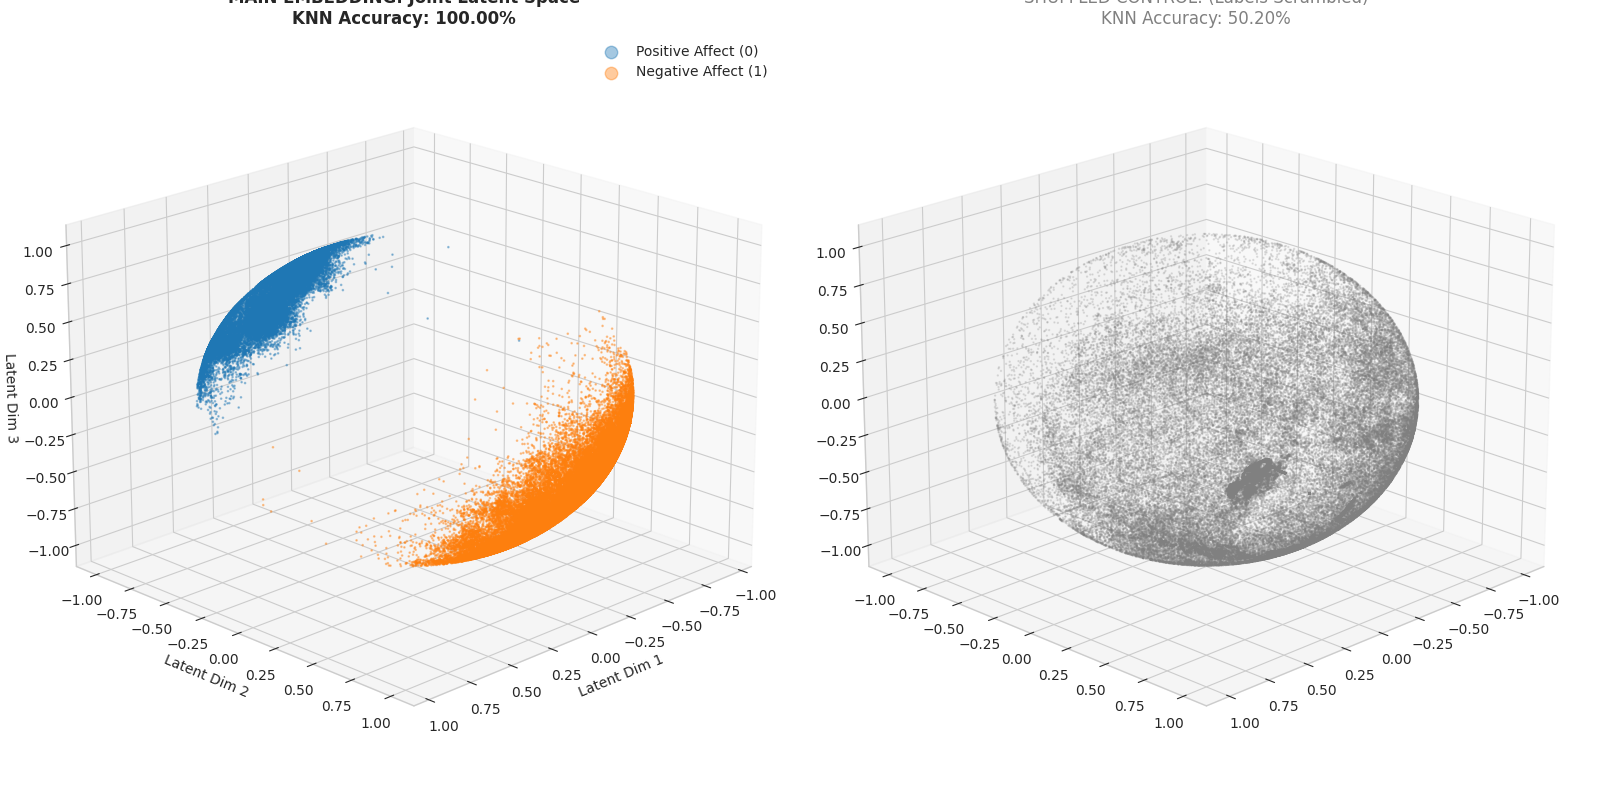

In [21]:
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ==========================================
# 1. CALCULATE METRICS & GOODNESS OF FIT
# ==========================================
def get_metrics(embedding, labels):
    # Standard 80/20 split for validation
    split = int(len(embedding) * 0.8)
    train_emb, test_emb = embedding[:split], embedding[split:]
    train_y, test_y = labels[:split], labels[split:]
    
    # GSoC requirement: Report KNN accuracy
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(train_emb, train_y)
    return knn.score(test_emb, test_y)

# Calculate scores for the titles
acc_main = get_metrics(embedding_main, full_y)
acc_control = get_metrics(embedding_control, y_shuffled)

# --- PRINTING THE REQUIRED GSOC METRICS ---
print(f"--- GSOC REQUIRED METRICS ---")
print(f"Main KNN Accuracy: {acc_main:.2%}")
print(f"Control KNN Accuracy: {acc_control:.2%}")
print(f"Main Goodness-of-Fit (Total Loss): {cebra_pos_neg.state_dict_['loss'][-1]:.4f}")
print(f"Control Goodness-of-Fit (Total Loss): {cebra_control.state_dict_['loss'][-1]:.4f}")
print(f"-----------------------------\n")


# ==========================================
# 2. SETUP STYLING & PLOT
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid') 
fig = plt.figure(figsize=(16, 8))

# High-contrast Cobalt and Sunset colors
pos_color = '#1f77b4' 
neg_color = '#ff7f0e'

# --- MAIN EMBEDDING ---
ax1 = fig.add_subplot(121, projection='3d')
idx_pos = (full_y == 0)
idx_neg = (full_y == 1)

ax1.scatter(embedding_main[idx_pos, 0], embedding_main[idx_pos, 1], embedding_main[idx_pos, 2], 
            c=pos_color, label='Positive Affect (0)', s=0.8, alpha=0.4)
ax1.scatter(embedding_main[idx_neg, 0], embedding_main[idx_neg, 1], embedding_main[idx_neg, 2], 
            c=neg_color, label='Negative Affect (1)', s=0.8, alpha=0.4)

ax1.view_init(elev=20, azim=45) 
ax1.set_title(f"MAIN EMBEDDING: Joint Latent Space\nKNN Accuracy: {acc_main:.2%}", fontweight='bold')
ax1.set_xlabel("Latent Dim 1")
ax1.set_ylabel("Latent Dim 2")
ax1.set_zlabel("Latent Dim 3")
ax1.legend(markerscale=10)

# --- CONTROL EMBEDDING ---
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(embedding_control[:, 0], embedding_control[:, 1], embedding_control[:, 2], 
            c='gray', s=0.5, alpha=0.2)

ax2.set_title(f"SHUFFLED CONTROL: (Labels Scrambled)\nKNN Accuracy: {acc_control:.2%}", color='gray')
ax2.view_init(elev=20, azim=45) 

plt.tight_layout()
plt.show()

## Part 4: Critical Reflection

**The Limitation of the Current Analysis**
The most significant limitation of my immediate analysis is the forced binary segmentation of the continuous data. By cropping the EEG files strictly between the DIN1 markers, I excised the intervening temporal data. In reality, human emotion and brain-to-brain synchrony shift along a continuous gradient. By feeding the model two isolated, highly contrasting emotional "islands," I forced CEBRA to act as a discrete classifier, resulting in an embedding that lacks the crucial transitional topology between the positive and negative states.

**Future Directions (With More Time and Data)**
If I had access to the full 40+ dyad dataset and an extended timeline, I would expand this pipeline in several key directions:

* **Alternative Preprocessing & Hypothesis Testing:** With a larger dataset, I would experiment with artifact rejection techniques beyond standard ICA. Having more dyadic pairs would provide the comparative baseline needed to rigorously test my hypotheses regarding which behavioral features (like specific facial EMG patterns) actually contain valid emotional data versus generic noise.
* **Advanced Topological Representations:** I am highly interested in exploring alternative mathematical representations of joint EEG data. Drawing on approaches like those outlined in *"Towards a new approach to reveal dynamical organization of the brain using topological data analysis,"* I would investigate how topological features might capture the dynamical organization of brain-to-brain coupling differently than contrastive learning alone.
* **Grounding ML in Behavioral Psychology:** I would dive deeper into real-world psychological literature. By better understanding how affective dynamics and gaze behaviors unfold in natural settings, I can design ML hypotheses and labeling strategies that are more biologically and psychologically valid.
* **Addressing Ecological Validity:** A lingering question is the impact of the experimental setup itself. Having participants converse in a highly controlled laboratory environment while wearing 64-channel EEG nets inherently alters the natural flow of conversation. While I am still considering the best methodological approach to account for this "observer effect," it is a crucial variable to keep in mind when interpreting the true naturalness of the recorded affective states.

Ultimately, exploring the intersection of machine learning, topological data analysis, and human psychology is incredibly fascinating to me. I thoroughly enjoyed this pre-task and would be thrilled to continue expanding on this work to uncover how our brains truly sync during conversation.